In [1]:
import numpy as np
import scipy.optimize as sci
import matplotlib.pyplot as plt

In [2]:
def model_sin(x, f, A, c):
    return A * np.sin(f * x * 2 * np.pi + c)

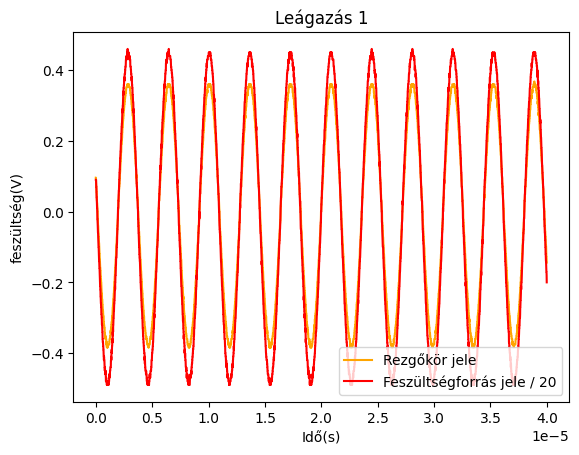

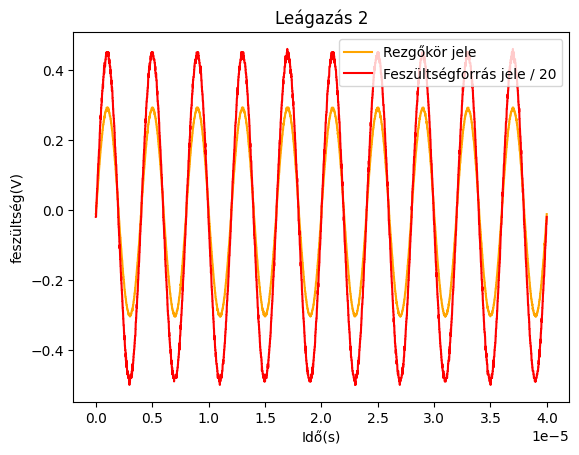

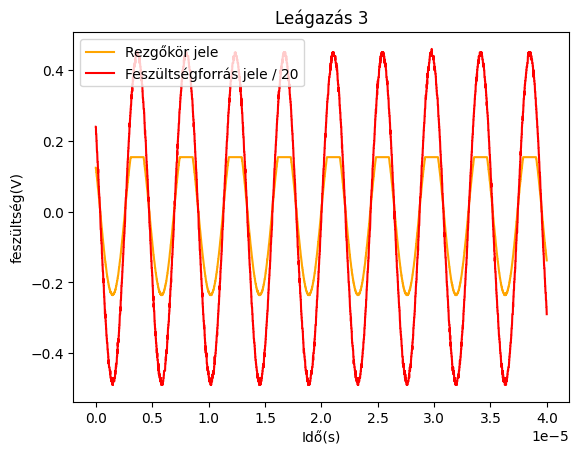

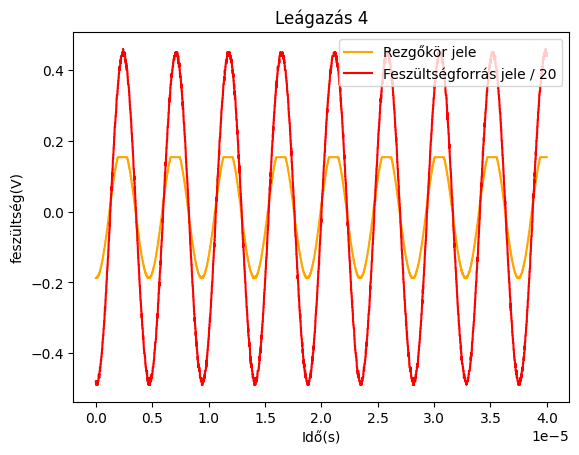

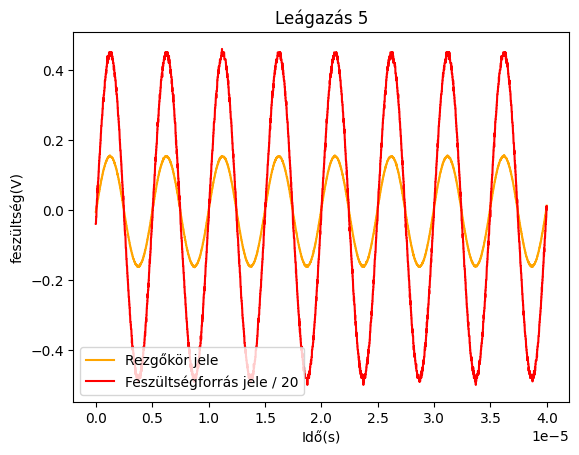

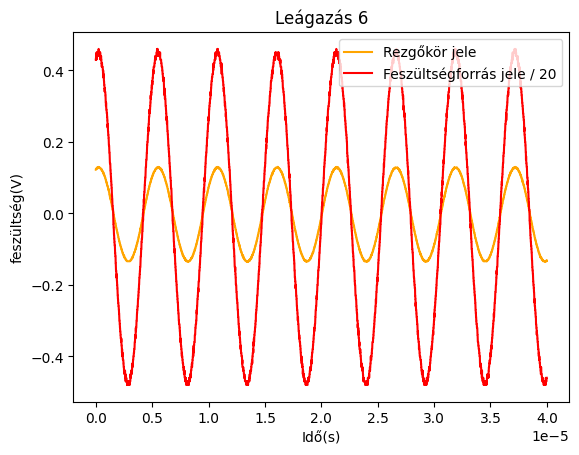

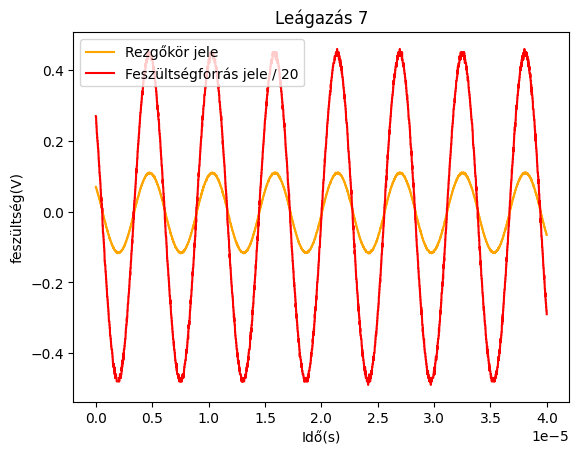

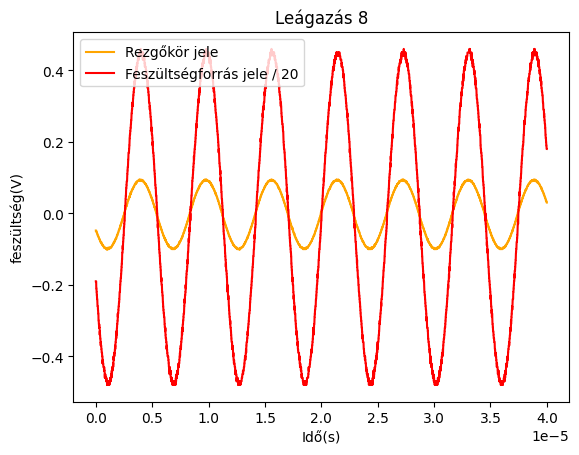

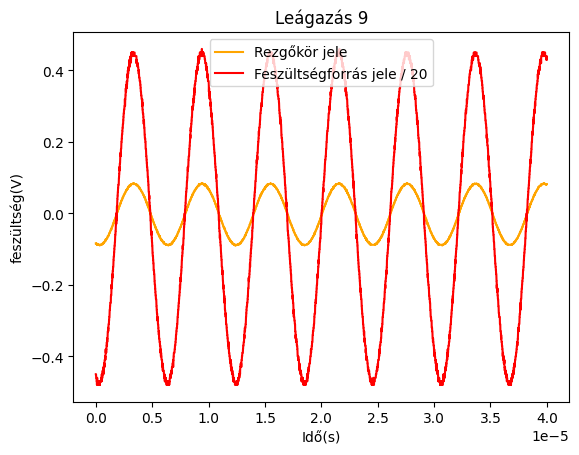

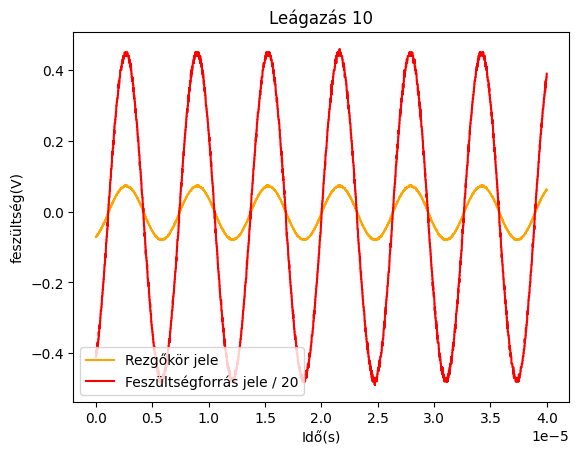

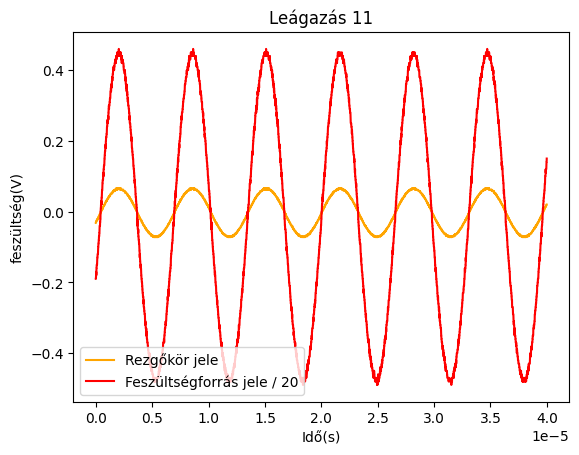

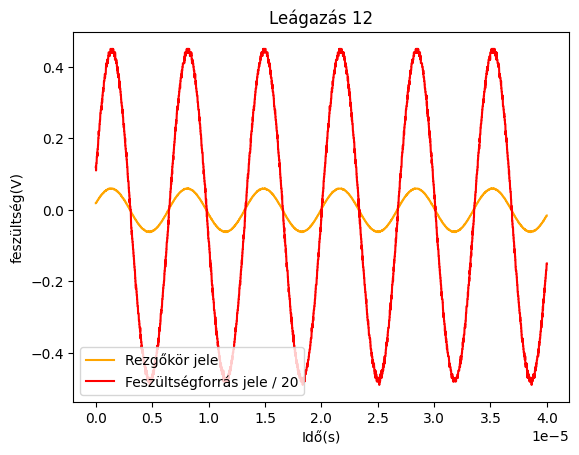

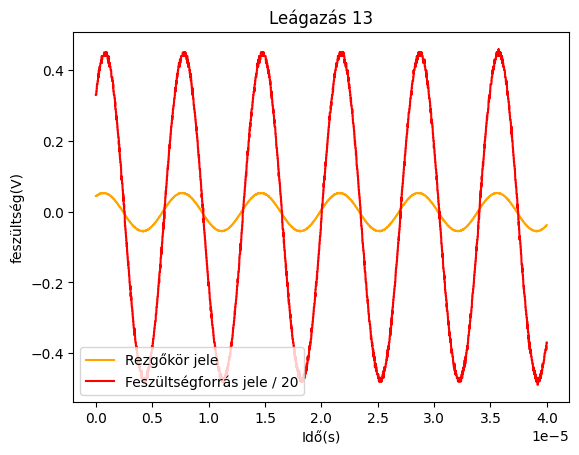

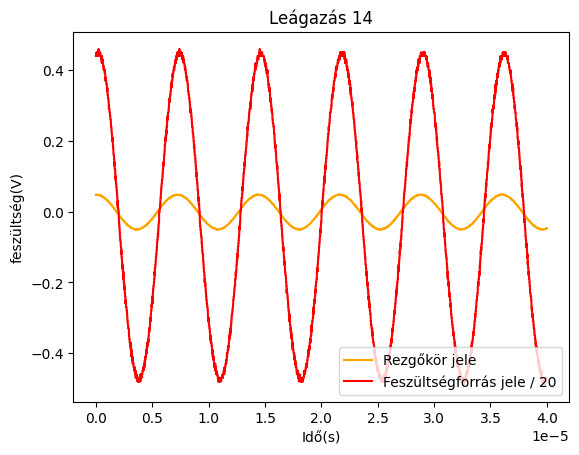

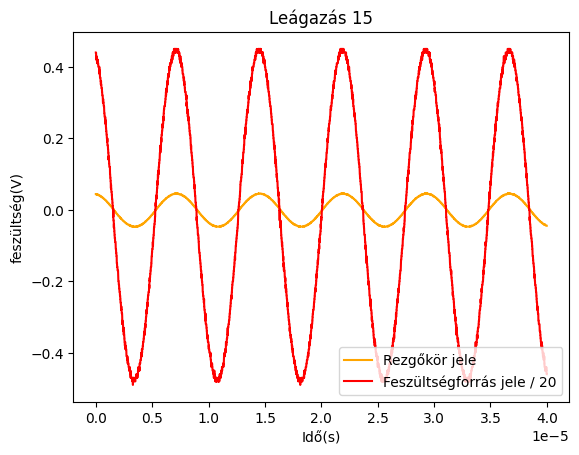

In [3]:
leagazasok = [np.loadtxt('./rezonancia_helye/leagazas_' + str(i + 1) + '.dat') for i in range(15)]
for i in range(15):
    plt.plot(leagazasok[i][:, 0], leagazasok[i][:, 1], "orange")
    plt.plot(leagazasok[i][:, 0], leagazasok[i][:, 2] / 20, "red")
    plt.xlabel("Idő(s)")
    plt.ylabel("feszültség(V)")
    plt.legend(["Rezgőkör jele", "Feszültségforrás jele / 20"])
    plt.title("Leágazás " + str(i + 1))
    plt.show()

In [4]:
majom = leagazasok[2][:,1]

In [5]:
kimeneti_parameterek = [None for i in range(15)]
bemeneti_parameterek = [None for i in range(15)]
kimeneti_hibak = [None for i in range(15)]
bemeneti_hibak = [None for i in range(15)]
minta_frekvenciak = [277560, 250260, 229720, 213580, 200480, 189520, 180060, 171960, 164840, 158480, 152980, 147880, 143300, 139060, 135400]

for i in range(15):
    kimeneti_parameterek[i], kimeneti_hibak[i] = sci.curve_fit(model_sin, leagazasok[i][:, 0], leagazasok[i][:, 1], p0=[minta_frekvenciak[i], 0.2, 0])
    bemeneti_parameterek[i], bemeneti_hibak[i] = sci.curve_fit(model_sin, leagazasok[i][:, 0], leagazasok[i][:, 2], p0=[minta_frekvenciak[i], 0.2, 0])

print(kimeneti_parameterek)
print(bemeneti_parameterek)

[array([ 2.77584548e+05, -3.71041514e-01, -2.80248694e-01]), array([ 2.50153638e+05,  2.96135692e-01, -3.61596396e-02]), array([ 2.29803702e+05, -2.08192849e-01, -5.74940108e-01]), array([ 2.13560811e+05,  1.78462825e-01, -1.60229921e+00]), array([ 2.00474636e+05,  1.57467796e-01, -2.02220567e-02]), array([1.89552719e+05, 1.31718476e-01, 1.26380244e+00]), array([ 1.80164963e+05, -1.13029782e-01, -6.98999114e-01]), array([ 1.71881777e+05, -9.66279227e-02,  4.48855847e-01]), array([ 1.64879634e+05, -8.59275272e-02,  1.22708254e+00]), array([ 1.58537184e+05,  7.61479041e-02, -1.11031480e+00]), array([ 1.52969198e+05,  6.83262036e-02, -4.04426046e-01]), array([1.47833650e+05, 6.05840407e-02, 3.18346328e-01]), array([1.43194633e+05, 5.39851388e-02, 9.64634791e-01]), array([1.39006028e+05, 4.90006438e-02, 1.52835522e+00]), array([ 1.35421646e+05, -4.62467443e-02, -1.36975332e+00])]
[array([ 2.77594464e+05, -9.32953750e+00,  1.23044896e+01]), array([ 2.50160928e+05,  9.29749910e+00, -1.272709

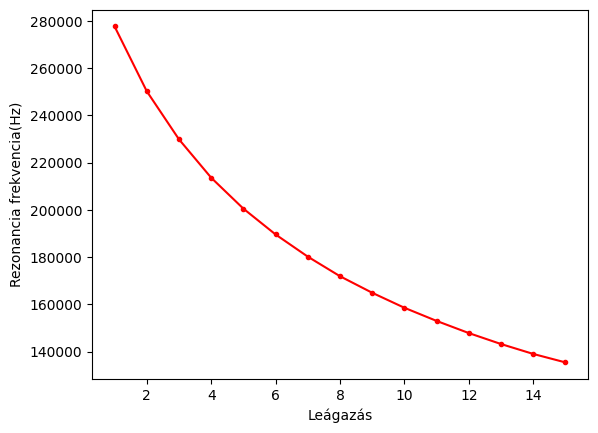

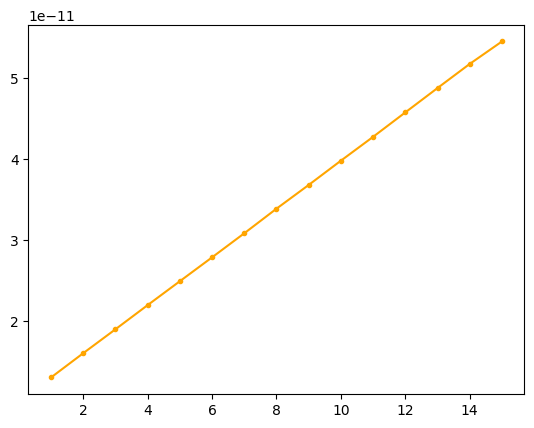

In [6]:
frekvenciak = np.array([kimeneti_parameterek[i][0] for i in range(15)])
leagazas_szam = np.array(range(1, 16)) 
plt.plot(leagazas_szam,  frekvenciak, ".-r")
plt.xlabel("Leágazás")
plt.ylabel("Rezonancia frekvencia(Hz)")
plt.show()
plt.plot(leagazas_szam,  1 / (frekvenciak ** 2), ".-", color="orange")
plt.show()

In [7]:
r_belso = (40.01 + 40.04 + 40.03 + 40.02 + 39.99) / 5 / 2 / 1000
d_kulso = (45.03 + 45.04 + 45.04 + 45.03 + 44.97) / 5 / 1000
h_folia = 0.415 / 1000
h_lemez = 1.88 / 1000
vastagsag = (2.28 + 2.04 + 2.11 + 2.13 + 2.18 + 2.73 + 2.69 + 2.69 + 2.60 + 2.59) / 10 / 1000
belso_sugar = (27.75 + 27.59 + 27.51 + 28.08 + 27.83) / 10 / 1000
hossz = (36.3 + 36.3 + 36.2) / 3 / 100
menetszam = 760

n = menetszam / hossz
def l(leagazas):
    return (menetszam - (15 - leagazas) * 40) / n
A_lemez = ((r_belso + d_kulso) ** 2 - r_belso ** 2) * np.pi
d = h_folia / 3
r = vastagsag + belso_sugar
print(belso_sugar * 2)


print(n)
print(d)
print(A_lemez)
print(r)



0.027752
2095.588235294118
0.00013833333333333333
0.012028124309621172
0.01628


In [8]:
for i in kimeneti_hibak:
    print(np.diag(np.sqrt(i)))

[8.24970711e+00 2.26028169e-04 1.20021419e-03]
[6.73809885e+00 1.45056792e-04 9.77210877e-04]
[3.44604512e+01 5.37510808e-04 5.02051635e-03]
[1.58850287e+01 2.03487160e-04 2.29505875e-03]
[8.04706295e+00 9.24754730e-05 1.16944404e-03]
[7.74723529e+00 7.24267538e-05 1.12223270e-03]
[8.74378928e+00 7.47618601e-05 1.27459291e-03]
[1.05116770e+01 7.13829035e-05 1.52096091e-03]
[1.17474170e+01 7.11498132e-05 1.70007328e-03]
[1.38600167e+01 7.97078917e-05 2.02221260e-03]
[1.42710909e+01 7.33380547e-05 2.07773268e-03]
[6.51831014e+00 2.79094574e-05 9.43955799e-04]
[7.59508914e+00 2.81382144e-05 1.09361274e-03]
[7.80019918e+00 2.71043915e-05 1.12151742e-03]
[7.70745898e+00 2.65546931e-05 1.12405427e-03]


C:\Users\kutykurutty\AppData\Local\Temp\ipykernel_11240\83177547.py:2: RuntimeWarning: invalid value encountered in sqrt
  print(np.diag(np.sqrt(i)))


In [9]:
for i in range(15):
    print(str(i + 1) + ".", end=" & ")
    print(minta_frekvenciak[i], end=" & ")
    print(int(kimeneti_parameterek[i][0]), end=" ")
    print("\\"+"\\")
    print("\\hline")
    

1. & 277560 & 277584 \\
\hline
2. & 250260 & 250153 \\
\hline
3. & 229720 & 229803 \\
\hline
4. & 213580 & 213560 \\
\hline
5. & 200480 & 200474 \\
\hline
6. & 189520 & 189552 \\
\hline
7. & 180060 & 180164 \\
\hline
8. & 171960 & 171881 \\
\hline
9. & 164840 & 164879 \\
\hline
10. & 158480 & 158537 \\
\hline
11. & 152980 & 152969 \\
\hline
12. & 147880 & 147833 \\
\hline
13. & 143300 & 143194 \\
\hline
14. & 139060 & 139006 \\
\hline
15. & 135400 & 135421 \\
\hline


In [10]:
L_jk = [l(i) for i in range(1, 16)]


t = np.linspace(0, 0.363, 100)

q = np.linspace(l(1), 0.363, 100)
print(L_jk)



[0.09543859649122806, 0.11452631578947367, 0.13361403508771927, 0.1527017543859649, 0.1717894736842105, 0.19087719298245612, 0.20996491228070172, 0.22905263157894734, 0.24814035087719294, 0.26722807017543854, 0.28631578947368413, 0.3054035087719298, 0.3244912280701754, 0.343578947368421, 0.3626666666666666]


In [11]:
trallalellotrallalla = np.sqrt((r ** 2) * np.pi * (n ** 2) * (A_lemez / d)) * 2 * np.pi
print(trallalellotrallalla)
print(r)
print(n)
print(A_lemez)
print(d)

3542.8330695772165
0.01628
2095.588235294118
0.012028124309621172
0.00013833333333333333


[8.00815852e+04 1.21640891e-02]
25.174815734114798
8.499169159061389e-05
80106.75999836969
0.012249080771332674


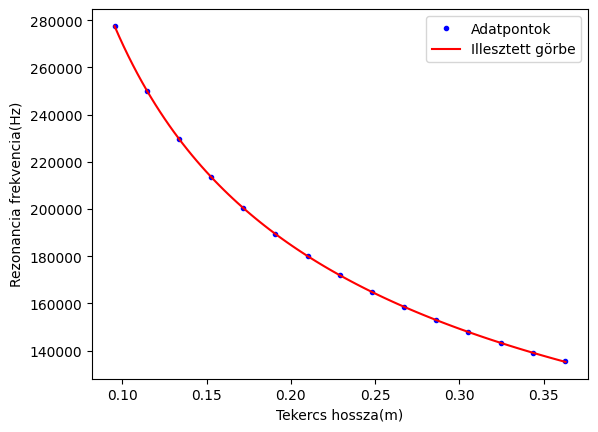

In [12]:
def engedd_el(l, c, alfa):
#    return c / (trallalellotrallalla * np.sqrt(l - r * alfa))
    return c / np.sqrt(l - alfa)
engedd_el_parameterek, engedd_el_hiba = sci.curve_fit(engedd_el, L_jk, frekvenciak, p0=[298360000, 0], maxfev = 2000)
print(engedd_el_parameterek)
print(np.sqrt(engedd_el_hiba[0][0]))
print(np.sqrt(engedd_el_hiba[1][1]))
print(np.sqrt(engedd_el_hiba[0][0]) + engedd_el_parameterek[0])
print(np.sqrt(engedd_el_hiba[1][1]) + engedd_el_parameterek[1])
plt.plot(L_jk, frekvenciak, ".b")
plt.xlabel("Tekercs hossza(m)")
plt.ylabel("Rezonancia frekvencia(Hz)")
p = np.array([engedd_el(q[i], engedd_el_parameterek[0], engedd_el_parameterek[1]) for i in range(100)])
plt.plot(q, p, "red")
plt.legend(["Adatpontok", "Illesztett görbe"])
plt.show()
engedd_el_hiba = np.sqrt(np.diag(engedd_el_hiba))

In [13]:

print(engedd_el_hiba)
print("c", end=" & ")
print(engedd_el_parameterek[0], end=" & ")
print(engedd_el_hiba[0], end=" ")
print("\\\\")
print("$\\beta$", end=" & ")
print(engedd_el_parameterek[1], end=" & ")
print(engedd_el_hiba[1], end=" ")
print("\\\\")


print(engedd_el_parameterek[1])

[2.51748157e+01 8.49916916e-05]
c & 80081.58518263556 & 25.174815734114798 \\
$\beta$ & 0.01216408907974206 & 8.499169159061389e-05 \\
0.01216408907974206


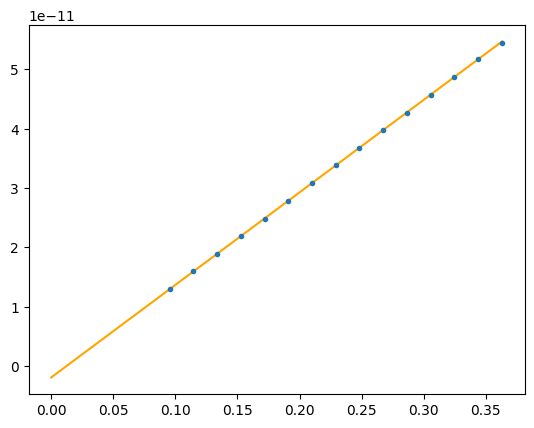

In [14]:
def linearis(x, a, b):
    return a * x + b

L_jk = [l(i) for i in range(1, 16)]

egyenes_parameterek, egyenes_hibak = sci.curve_fit(linearis, L_jk, 1 / frekvenciak ** 2)
z = np.array([linearis(t[i], egyenes_parameterek[0], egyenes_parameterek[1]) for i in range(100)])



plt.plot(t, z, "orange")
plt.plot(L_jk, 1 / frekvenciak ** 2, ".")
plt.show()

In [15]:
print(np.sqrt(1 / (egyenes_parameterek[0] / (4 * np.pi ** 3 * A_lemez / d * n ** 2 * r ** 2))))
print(egyenes_parameterek[0])
print(egyenes_parameterek[1] / (4 * np.pi ** 3 * A_lemez / d * n ** 2 * r ** 3) * (1 / (egyenes_parameterek[0] / (4 * np.pi ** 3 * A_lemez / d * n ** 2 * r ** 2))))

print(np.sqrt(egyenes_hibak[0][0]))

283709053.72806287
1.5593908772741945e-10
-0.7476247548569953
1.5396289317839185e-13


[np.float64(0.00014782031114060067), np.float64(0.00016192092556973595), np.float64(0.0001540445935941502), np.float64(0.00014840896159947102), np.float64(0.00014999540733238266), np.float64(0.00014849800870454693), np.float64(0.00014466500099259632), np.float64(0.00015462295754667155), np.float64(0.00014657890669326918), np.float64(0.00015457744964442885), np.float64(0.00014505679118481676), np.float64(0.00015147060230364084), np.float64(0.00015683472538791487), np.float64(0.00014942188142927923), np.float64(0.00015469187075812079), np.float64(0.00014453328894879032), np.float64(0.00016480885807743797), np.float64(0.00014900374224356737), np.float64(0.00015837949640829608), np.float64(0.00015580788392232042), np.float64(0.00014942254045074334)]


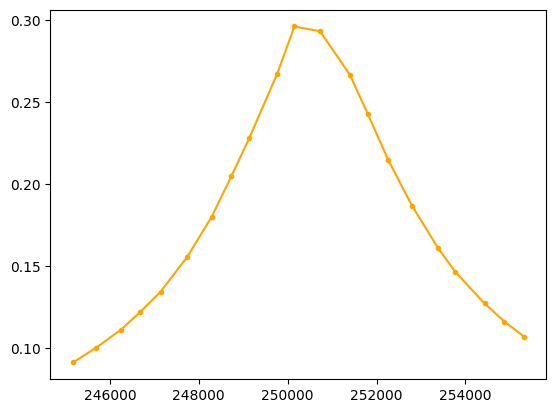

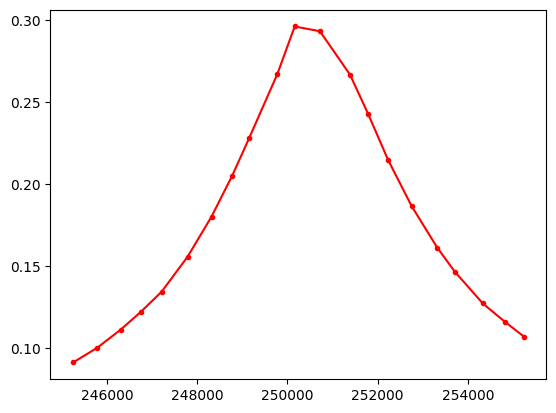

In [16]:
rezonanciak = []
for i in range(10, 0, -1):
    rezonanciak.append(np.loadtxt('./rezonancia_gorbe/rezonancia_+' + str(i) + '.dat'))
rezonanciak.append(np.loadtxt('./rezonancia_gorbe/rezonancia_0.dat'))
for i in range(10):
    rezonanciak.append(np.loadtxt('./rezonancia_gorbe/rezonancia_-' + str(i + 1) + '.dat'))

parameterek = [None for i in range(21)]
hibak = [None for i in range(21)]
for i in range(21):
    parameterek[i], hibak[i] = sci.curve_fit(model_sin, rezonanciak[i][:, 0], rezonanciak[i][:, 1], p0=[250000, 0.2, 0])

for i in range(21):
    hibak[i] = np.sqrt(hibak[i][1][1])
print(hibak)

bemeneti_adatok = [None for i in range(21)]
bemeneti_h = [None for i in range(21)]

for i in range(21):
    bemeneti_adatok[i], bemeneti_h[i] = sci.curve_fit(model_sin, rezonanciak[i][:, 0], rezonanciak[i][:, 2], p0=[250000, 0.2, 0])

bemeneti_frekvenciak = np.array([i[0] for i in bemeneti_adatok])

frekvanciak = np.array([i[0] for i in parameterek])
amplitudok = np.array([np.abs(i[1]) for i in parameterek])

plt.plot(frekvanciak, amplitudok, ".-" ,color="orange")
plt.show()
plt.plot(bemeneti_frekvenciak, amplitudok, ".-", color="red")
plt.show()

In [17]:
for i in  range(21):
    print(str(i + 1) + ".", end=" & ")
    print(int(bemeneti_frekvenciak[i]), end=" & ")
    print('{:.6}'.format(amplitudok[i]), end=" & ")
    print('{:.3}'.format(hibak[i]), end=" ")
    print("\\\\")

1. & 255241 & 0.107116 & 0.000148 \\
2. & 254813 & 0.116271 & 0.000162 \\
3. & 254330 & 0.127295 & 0.000154 \\
4. & 253708 & 0.146707 & 0.000148 \\
5. & 253322 & 0.161261 & 0.00015 \\
6. & 252752 & 0.186645 & 0.000148 \\
7. & 252232 & 0.214687 & 0.000145 \\
8. & 251788 & 0.242823 & 0.000155 \\
9. & 251387 & 0.266766 & 0.000147 \\
10. & 250720 & 0.293238 & 0.000155 \\
11. & 250160 & 0.296136 & 0.000145 \\
12. & 249775 & 0.267086 & 0.000151 \\
13. & 249150 & 0.228024 & 0.000157 \\
14. & 248773 & 0.205013 & 0.000149 \\
15. & 248318 & 0.180278 & 0.000155 \\
16. & 247786 & 0.155767 & 0.000145 \\
17. & 247211 & 0.134431 & 0.000165 \\
18. & 246745 & 0.122012 & 0.000149 \\
19. & 246305 & 0.111371 & 0.000158 \\
20. & 245778 & 0.10017 & 0.000156 \\
21. & 245247 & 0.091326 & 0.000149 \\


In [18]:
def Lorentz_gorbe(f, f_0, M, B):
    return M / np.sqrt((f - f_0) ** 2 + B ** 2 / 4)

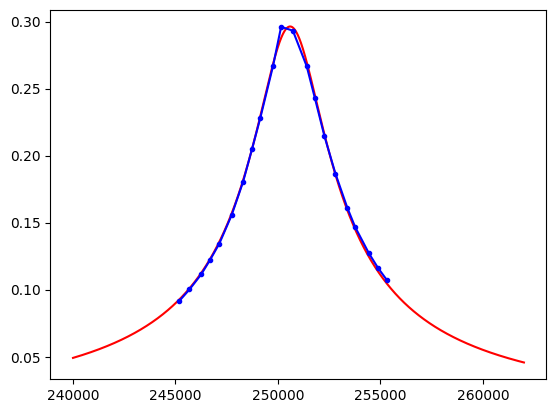

In [19]:
Lorentz_parameterek , Lorentz_hibak = sci.curve_fit(Lorentz_gorbe, frekvanciak, amplitudok, p0=[250276, 0.3, 2500])
jo_Lorentz_parameterek , jo_Lorentz_hibak = sci.curve_fit(Lorentz_gorbe, bemeneti_frekvenciak, amplitudok, p0=[250276, 0.3, 2500])


f = np.linspace(240000, 262000, 10000)

a = [Lorentz_gorbe(f[i], Lorentz_parameterek[0], Lorentz_parameterek[1], Lorentz_parameterek[2]) for i in range(10000)]
plt.plot(f, a, "red")
plt.plot(frekvanciak, amplitudok, ".-" ,color="blue")
plt.show()


In [20]:
print(f[a.index(max(a))])
print(f[a.index(max(a))] / Lorentz_parameterek[2])
print(Lorentz_parameterek[2])

250591.85918591858
70.41261549586326
3558.9057077512034


[250592.39368862    527.39435146   3558.90570775]
[250589.41794285    518.05264001  -3494.62221688]
[[0.00014782031114060067, 0.00016192092556973595, 0.0001540445935941502, 0.00014840896159947102, 0.00014999540733238266, 0.00014849800870454693, 0.00014466500099259632, 0.00015462295754667155, 0.00014657890669326918, 0.00015457744964442885, 0.00014505679118481676, 0.00015147060230364084, 0.00015683472538791487, 0.00014942188142927923, 0.00015469187075812079, 0.00014453328894879032, 0.00016480885807743797, 0.00014900374224356737, 0.00015837949640829608, 0.00015580788392232042, 0.00014942254045074334], [0.00014782031114060067, 0.00016192092556973595, 0.0001540445935941502, 0.00014840896159947102, 0.00014999540733238266, 0.00014849800870454693, 0.00014466500099259632, 0.00015462295754667155, 0.00014657890669326918, 0.00015457744964442885, 0.00014505679118481676, 0.00015147060230364084, 0.00015683472538791487, 0.00014942188142927923, 0.00015469187075812079, 0.00014453328894879032, 0.00016480

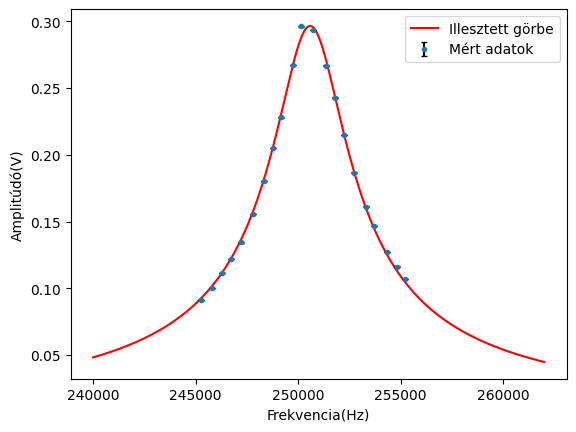

In [21]:
print(Lorentz_parameterek)
print(jo_Lorentz_parameterek)
yerr = [[float(i) for i in hibak], [float(i) for i in hibak] ]
print(yerr)
b = [Lorentz_gorbe(f[i], jo_Lorentz_parameterek[0], jo_Lorentz_parameterek[1], jo_Lorentz_parameterek[2]) for i in range(10000)]
plt.plot(f, b, "red")
plt.errorbar(bemeneti_frekvenciak, amplitudok, capsize=2, yerr=yerr, fmt=".", ecolor="black")
plt.ylabel("Amplitúdó(V)")
plt.xlabel("Frekvencia(Hz)")
plt.legend(["Illesztett görbe", "Mért adatok"])
plt.show()

In [22]:
print(f[b.index(max(b))])
print(f[b.index(max(b))] / jo_Lorentz_parameterek[2])

250589.65896589658
-71.70722424738433


In [23]:
minta_frekvenciak = np.array([277560, 250260, 229720, 213580, 200480, 189520, 180060, 171960, 164840, 158480, 152980, 147880, 143300, 139060, 135400])
gyo, gyo_hiba = sci.curve_fit(engedd_el, L_jk, minta_frekvenciak)
print(gyo)
kota = [277552, 250272, 229694, 213576, 200492, 189506, 180034, 171960, 164834, 158454, 152998, 147876, 143292, 139036, 135396]
kota = np.array(kota)
gyogyos, gyogyos_hiba = sci.curve_fit(engedd_el,L_jk, kota)
print(gyogyos)

[1. 1.]
[1. 1.]


C:\Users\kutykurutty\AppData\Local\Temp\ipykernel_11240\2095432767.py:3: RuntimeWarning: invalid value encountered in sqrt
  return c / np.sqrt(l - alfa)
C:\Users\kutykurutty\AppData\Local\Temp\ipykernel_11240\2372169590.py:2: OptimizeWarning: Covariance of the parameters could not be estimated
  gyo, gyo_hiba = sci.curve_fit(engedd_el, L_jk, minta_frekvenciak)
C:\Users\kutykurutty\AppData\Local\Temp\ipykernel_11240\2372169590.py:6: OptimizeWarning: Covariance of the parameters could not be estimated
  gyogyos, gyogyos_hiba = sci.curve_fit(engedd_el,L_jk, kota)


In [24]:
mc = [245.28, 245.78, 246.28, 246.78, 247.28, 247.78, 248.28, 248.78, 249.28, 249.78, 250.28, 250.78, 251.28, 251.78, 252.28, 252.78, 253.28, 253.78, 254.28, 254.78, 255.28]
mc = np.array(mc) * 1000
isti = [184, 200, 224, 244, 276, 308, 352, 408, 468, 528, 600, 576, 540, 484, 424, 368, 324, 288, 264, 232, 208]
isti = np.array(isti) / 1000 / 2

etkar, etkar_hiba = sci.curve_fit(Lorentz_gorbe, mc, isti, p0=jo_Lorentz_parameterek)

[250596.33277332    517.72439826  -3527.48637125]
[250589.41794285    518.05264001  -3494.62221688]


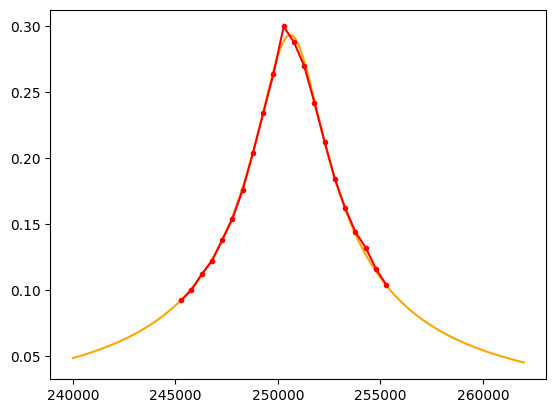

In [25]:
print(etkar)
print(jo_Lorentz_parameterek)
asda = [Lorentz_gorbe(f[i], etkar[0], etkar[1], etkar[2]) for i in range(10000)]
plt.plot(f, asda, "orange")
plt.plot(mc, isti, ".-r")
plt.show()

[250588.02015061    517.69780779   3527.02170394]
[250589.41794285    518.05264001  -3494.62221688]


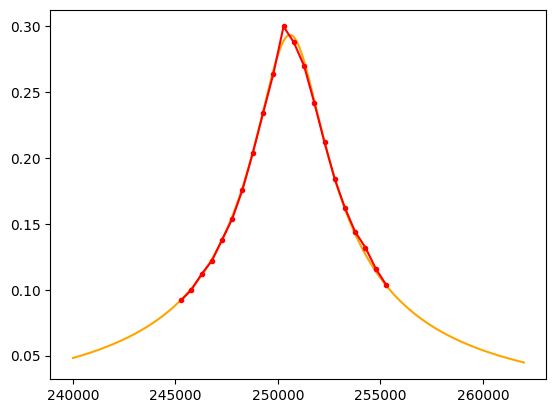

In [26]:
stu =  [245270, 245774, 246274, 246772, 247270, 247770, 248268, 248774, 249270, 249774, 250272, 250770, 251276, 251772, 252270, 252772, 253272, 253768, 254270, 254774, 255270]
stu = np.array(stu)
norbert, norbert_hibak = sci.curve_fit(Lorentz_gorbe, stu, isti, p0=Lorentz_parameterek)
print(norbert)
print(jo_Lorentz_parameterek)
asdawa = [Lorentz_gorbe(f[i], norbert[0], norbert[1], norbert[2]) for i in range(10000)]
plt.plot(f, asdawa, "orange")
plt.plot(stu, isti, ".-r")
plt.show()

In [27]:
for i in range(1,16):
    print(i, end=". & ")
    print(760-(15-i)*40, end=" & ")
    print('{:.6f}'.format(l(i)), end=" & ")
    print('{:.6f}'.format(l(i) * 0.001379), end=" ")
    print("\\\\")


1. & 200 & 0.095439 & 0.000132 \\
2. & 240 & 0.114526 & 0.000158 \\
3. & 280 & 0.133614 & 0.000184 \\
4. & 320 & 0.152702 & 0.000211 \\
5. & 360 & 0.171789 & 0.000237 \\
6. & 400 & 0.190877 & 0.000263 \\
7. & 440 & 0.209965 & 0.000290 \\
8. & 480 & 0.229053 & 0.000316 \\
9. & 520 & 0.248140 & 0.000342 \\
10. & 560 & 0.267228 & 0.000369 \\
11. & 600 & 0.286316 & 0.000395 \\
12. & 640 & 0.305404 & 0.000421 \\
13. & 680 & 0.324491 & 0.000447 \\
14. & 720 & 0.343579 & 0.000474 \\
15. & 760 & 0.362667 & 0.000500 \\


In [28]:
hujujujj = np.sqrt(np.diag(jo_Lorentz_hibak))

In [29]:
print(jo_Lorentz_parameterek)
print()
print(hujujujj)

[250589.41794285    518.05264001  -3494.62221688]

[13.33910313  3.63146639 36.29308261]


In [30]:
d_belso = [0.0275, 0.02759, 0.02751, 0.02808, 0.02783]
h_pvc = [0.00228, 0.00204, 0.00211, 0.00213, 0.00218]
h_drot = [0.00273, 0.00269, 0.00269, 0.00260, 0.00259]

In [31]:
def szoras(adatok):
    atlag = 0
    for i in adatok:
        atlag += i
    atlag /= len(adatok)
    szor = 0
    for i in adatok:
        szor += (atlag - i) ** 2
    szor /= len(adatok)
    return np.sqrt(szor)

def atlag(adatok):
    atlag = 0
    for i in adatok:
        atlag += i
    return atlag / len(adatok)

In [36]:
print((szoras(d_belso) + 0.000005))
print((szoras(h_pvc) + 0.000005))
print((szoras(h_drot) + 0.000005))
print((szoras(d_belso) + 0.000005)/atlag(d_belso))
print((szoras(h_pvc) + 0.000005)/atlag(h_pvc))
print((szoras(h_drot) + 0.000005)/atlag(h_drot))
ga = (szoras(h_drot) + szoras(h_pvc))/2 + (szoras(d_belso) / 2) + (0.000005 * 3 /2)
ag = (atlag(h_drot) + atlag(h_pvc) + atlag(d_belso))/2
print(ga)
print(ga/ag)

x = (ga/ag * 2 + 2.889/2095.6 * 2 + 3.595e-4 + 1.25e-2)/2 + (25.17/80081.6)
dc = 283655677 * x
print(dc)
print((ga/ag + 2.499e-5/0.0121641) * 0.747181)

0.0002283741256278358
8.484985911070846e-05
6.013619500836092e-05
0.00824395804013558
0.039501796606475084
0.02260759210840636
0.00018668008987345256
0.011484471847028764
5561673.46280999
0.010115992287109741


In [35]:
print(ga/ag + 2.499e-5/0.0121641)

0.01353887784500642
